# Analysis on the Relationship CPU Utilization and Temperature on Raspberry Pi Devices

Link to Github page: [https://github.com/CuriousChum/jsc370](https://github.com/CuriousChum/jsc370)

## Introduction

### Background
Edge computing devices such as Raspberry Pis have started gaining popularity due to their minimal design and affordable price tag. Unlike their bulkier counterpart, Raspberry Pis are small, yet powerful enough to act as a miniature personal computer (PC). This makes them suitable for specialized tasks such as gathering field data. However, due to their size and the rising demand in performance, the temperature within the device motherboard can rise quickly. The motherboard, being in the center of the device, is affected by the activity of peripheral devices and may wear out from intensive use. 

This analysis aims explores the relationship between device resources utilization and temperature across different Raspberry Pi specifications. The goal is to understand how different workloads affect device temperature (as measured by sensors in the motherboard) and whether this relationship can be used to predict thermal behavior under various application usages and resource utilization. This information is valuable for optimizing edge computing applications by anticipating device wear out and CPU throttling due to overheating.

### Research Question

How does resource utilization affect device temperature across different Raspberry Pi configurations and application states, and can we identify patterns in this relationship to predict overall device temperature?

## Methods

### Dataset Description

The dataset used in this analysis was constructed and collected by researched is the Queen's Telecommunation Research Lab (TRL), led by Ruslan Kain. It contains resource usage information from four heterogeneous Raspberry Pi 4 devices, with different RAM sizes (2GB, 4GB, 8GB) and CPU frequencies (1200MHz, 1500MHz, 1800MHz), measured under different application usages including gaming, streaming, augmented reality, mining, and idling. The data is collected in ~5 second intervals using the `PsUtil` Python package.

The dataset includes measurements from usages with random and periodic workloads using different Raspberry Pis. Each `.tab` file in the dataset contains data on a 'run' of a device. The tables are denoted as `<device specification>_res_usage_data_*.tab`. The runs included in this analysis are only from files that matches the following pattern: `<device specification>_res_usage_data_rvp_*.tab`.

{numref}`tbl-vars` lists all the variables regarding to device resource information during each run of the Raspberry Pi 4s that is given in the dataset.

```{table} Variable Descriptions
:name: tbl-vars
| Variable Name       | Description                                                                                      |
|---------------------|--------------------------------------------------------------------------------------------------|
| `cpu`               | System-wide CPU utilization as a percentage (%)                                                  |
| `cpu_freq`          | System-wide CPU cycle frequency (MHz)                                                            |
| `state`             | Label feature for the resource-usage state of the device associated with the running application |
| `memory`            | Memory currently in use or very recently used, as a percentage of RAM (%)                        |
| `net_upload_rate`   | Number of bytes sent in the last time interval, divided by the time interval (MBytes/s)          |
| `net_download_rate` | Number of bytes received in the last time interval, divided by the time interval (MBytes/s)      |
| `temp`              | Device temperature (°C)                                                                          |
```

### Data Wrangling

The dataset contains a lot of columns, some of which are redundant, filled with only zeros, or describes irrelevant information; these columns will thus be dropped from the analysis.

First, columns describing CPU time spent will be dropped since the focus is mainly on overall CPU utilization, so `cpu` and `cpu_freq` is sufficient. Manual inspection of the data shows that the columns `gpu` and `gpu_memory` are always zero, implying that the builtin GPU is not utilized in any of the workloads, so it is drop. Furthermore, the columns `link_quality_max` and `link_quality` are dropped because of the lack of documentation; the exact descriptions cannot be found in the `PsUtil` package. Finally, the columns `wifi_freq`, `net_sent`, and `net_recv` are dropped because these are already better represented by `net_upload_rate` and `net_download_rate`; note that `wifi_freq` is not indicative of device resource usage and both `net_*` features are cumulative sums of the `net_*_rate`s, respectively.

Next, the tables from the dataset will be combined while preserving per-device and per-run information using the columns `pi_id` and `run_id`, respectively. For brevity, the devices will be denoted as follows

- `dev0`: Raspberry Pi 4, 2GB RAM, 1200 MHz
- `dev1`: Raspberry Pi 4, 2GB RAM, 1500 MHz
- `dev2`: Raspberry Pi 4, 4GB RAM, 1500 MHz
- `dev3`: Raspberry Pi 4, 8GB RAM, 1800 MHz

Meanwhile, `run_id` ranges from `000` to `018`, each table in the initial dataset is considered a different run, irrespective of the device.

The final pruned dataset contains columns that is described in {numref}`tbl-vars-pruned`.  
```{table} Pruned Variable Descriptions
:name: tbl-vars-pruned
| Variable Name       | Description                                                                                      |
|---------------------|--------------------------------------------------------------------------------------------------|
| `cpu`               | System-wide CPU utilization as a percentage (%)                                                  |
| `cpu_freq`          | System-wide CPU cycle frequency (MHz)                                                            |
| `state`             | Label feature for the resource-usage state of the device associated with the running application |
| `memory`            | Memory currently in use or very recently used, as a percentage of RAM (%)                        |
| `net_upload_rate`   | Number of bytes sent in the last time interval, divided by the time interval (MBytes/s)          |
| `net_download_rate` | Number of bytes received in the last time interval, divided by the time interval (MBytes/s)      |
| `temp`              | Device temperature (°C)                                                                          |
| `pi_id`              | Device id, one of `dev0`, `dev1`, `dev2`, `dev3` |
| `run_id`              | Run id, ranges from `000` to `018` |
```


In [1]:
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error as mse
from xgboost import XGBRegressor

import math
import importlib
import gc

import utils

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://borealisdata.ca/api/access/dataset/:persistentId"
rpi_id = "doi:10.5683/SP3/GOZAJE"
params = {
    "persistentId": rpi_id,
}
force = False
if force:
    utils.get_data_from_remote(url, params)

In [3]:
COLS = [
    'time_stamp', 'time', 'state', 'cpu', 'cpu_freq',
    'memory', 'net_upload_rate', 'net_download_rate', 'temp',
    'gpu'
]
fnames = utils.get_filenames()

runs = []
for i, f in enumerate(fnames):
    runs.append(utils.load_one(f, run_id=f"{i:03d}", cols=COLS))

df_all = pl.concat(runs, how="diagonal")
states = np.sort(df_all["state"].unique())

## Exploratory Data Analysis

Since each run is a time-series data, comparing each feature directly might not be ideal. Instead, the comparison will either be done over time, or on the differences.

### Comparison over Time

Since it's infeasible to visualize and compare all runs with more than 30,000 observations, we instead sample one run from different devices and look at random sections within it. {numref}`fig-time0`, {numref}`fig-time1`, {numref}`fig-time2`, {numref}`fig-time3` are sections of runs that are chosen uniformly at random for each device.

In [4]:
np.random.seed(1000)
chosen = {}
for dev, runs in df_all[["pi_id", "run_id"]].unique().group_by("pi_id"):
    chosen[dev[0]] = np.random.choice(runs["run_id"], size=1)[0]

In [5]:
def sample_section(df):
    n_take = math.ceil(len(df) * 0.1)
    start = np.random.randint(0, len(df) - n_take)  
    return df[start:start + n_take - 1] # be safe, don't crash for no reason

def plot_dev_mult_time_series(dev):
    plotdf = sample_section(
        df_all.filter(
            (pl.col("pi_id") == dev) & (pl.col("run_id") == chosen[dev])
        )
    )
    return utils.plot_mult_time_series(
        plotdf,
        ['cpu', "cpu_freq", 'temp', "memory", "gpu", "net_upload_rate", "net_download_rate"],
        ylabs=['CPU usage (%)', 'CPU frequency', 'Temperature (Celcius)', "Memory",
               "GPU usage (%)", "Net Upload Rate (MBps)", "Net Download Rate (MBps)"
              ],
        suptitle=f'Resource Activity and Temperature over Time for device {dev} on run {chosen[dev]}'
    )


FileNotFoundError: [Errno 2] No such file or directory: 'images/fig-time0.png'

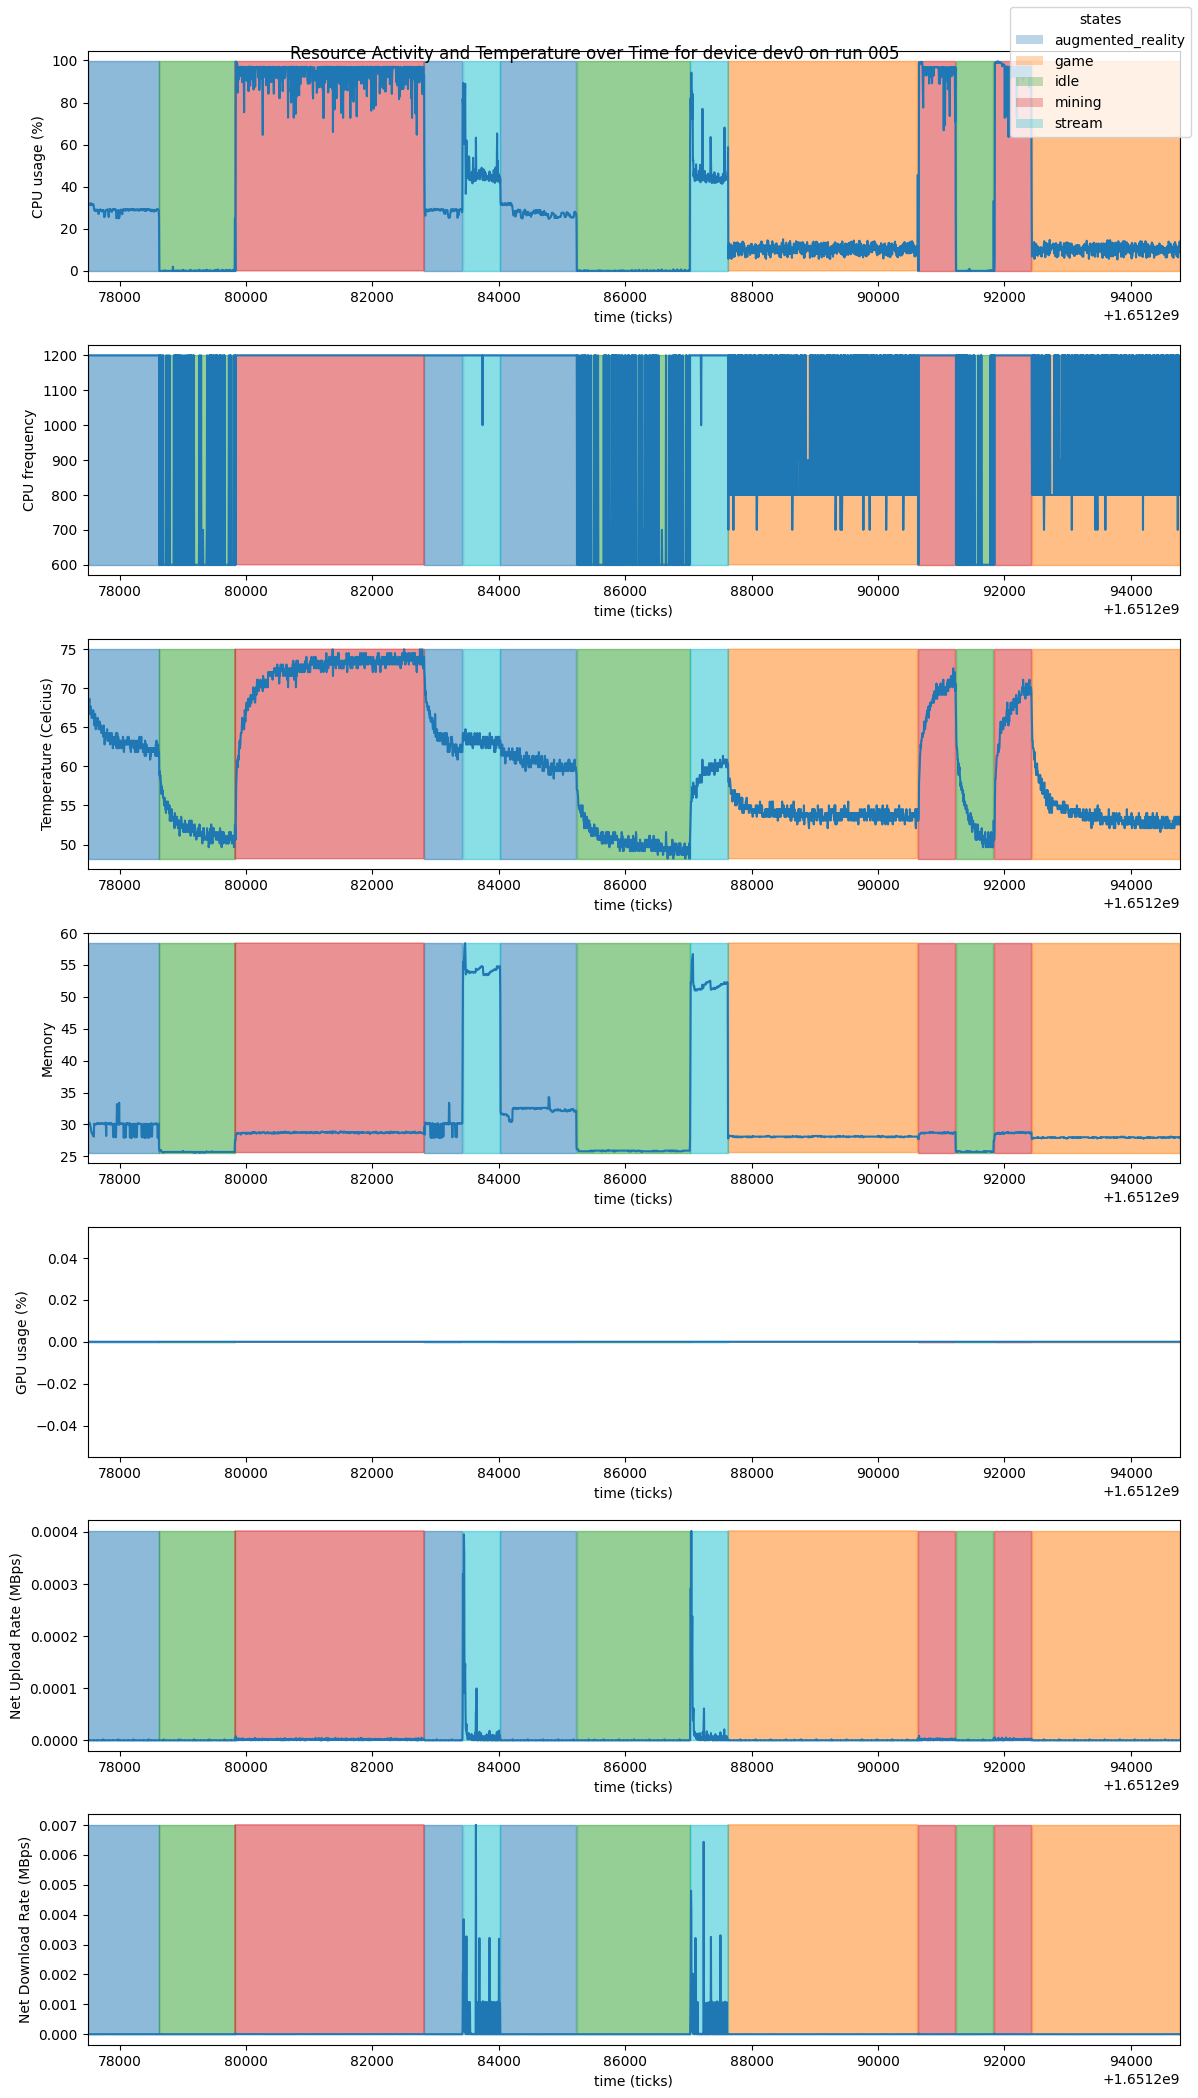

In [6]:
fig, axs = plot_dev_mult_time_series('dev0')
fig.savefig("images/fig-time0.png")
plt.close(fig)
fig, axs = plot_dev_mult_time_series('dev1')
fig.savefig("images/fig-time1.png")
plt.close(fig)
fig, axs = plot_dev_mult_time_series('dev2')
fig.savefig("images/fig-time2.png")
plt.close(fig)
fig, axs = plot_dev_mult_time_series('dev3')
fig.savefig("images/fig-time3.png")
plt.close(fig)

```{figure} images/fig-time0.png
:name: fig-time0
:align: center
```
```{figure} images/fig-time1.png
:name: fig-time1
:align: center
```
```{figure} images/fig-time2.png
:name: fig-time2
:align: center
```
```{figure} images/fig-time3.png
:name: fig-time3
:align: center
```

Firstly, for completeness, as mentioned before, we notice that GPU activity is nonexistent, and so it is dropped.
The plots shows several notable things: device temperature tends to move to a certain semi-constant value on each state, similarly CPU usage tends to move to a constant value with some occasional jumps every state. CPU frequency, however, appears to erratically jump from high to low, this is a phenomenon called throttling, where the CPU dynamically changes its frequency due to some circumstance, either due to low usage (as to preserve energy), or due to overheating, which is not seen here.
Finally, we see that the network activity is relevant when the device is streaming, specifically, the download rate increases. However, on any other states, the device shows little to no network activity, so the upload rate will be  dropped from future analyses. 

### Comparison per Device per State 


Then, we visualize the distribution of features per device colored by state. The following figures shows the aggregated distribution over all runs. Net download rate is not included in this visualization due to its very small value.

In [ ]:
def plot_activity(df, dev, cols, ylabs=None, suptitle=None):
    fig, ax = plt.subplots(ncols=1, nrows=len(cols), figsize=(12, 10))
    ylabs = ylabs if ylabs is not None else cols
    for i, col in enumerate(cols):
        idx = i
        sns.histplot(df, x=col, hue='state', ax=ax[idx], bins=50, hue_order=states, kde=True)
        ax[idx].set_xlabel('time (ticks)')
        ax[idx].set_ylabel(ylabs[i])
    fig.suptitle(f'Resource Activity in {dev}')
    return fig, ax

cols = ["cpu", "cpu_freq", "memory", "temp"]
fig, ax = plot_activity(
    df_all.filter(pl.col("pi_id") == "dev0"), "dev0", cols)
fig.savefig("images/pa0.png")
plt.close(fig)
fig, ax = plot_activity(
    df_all.filter(pl.col("pi_id") == "dev1"), "dev1", cols)
fig.savefig("images/pa1.png")
plt.close(fig)
fig, ax = plot_activity(
    df_all.filter(pl.col("pi_id") == "dev2"), "dev2", cols)
fig.savefig("images/pa2.png")
plt.close(fig)
fig, ax = plot_activity(
    df_all.filter(pl.col("pi_id") == "dev3"), "dev3", cols)
fig.savefig("images/pa3.png")
plt.close(fig)

```{figure} images/pa0.png
:name: fig-pa0
:align: center
```
```{figure} images/pa1.png
:name: fig-pa1
:align: center
```
```{figure} images/pa2.png
:name: fig-pa2
:align: center
```
```{figure} images/pa3.png
:name: fig-pa3
:align: center
```

### Feature Engineering
Resource activity data can contain a lot of noise especially for the CPU, upload/download rate (network), and temperature perhaps due to inherent jitter or measurement variance. For those columns, we will calculate a moving average to smoothen them out. The window size and weighing method is chosen based on the type of resource. Specifically, CPU and upload/download rate is unweighted, while temperature is weighted with an exponential window.

Memory usage on its own does affect the utilization of other resources since this can mean nothing is going on at the moment. So, the percentage change in RAM usage is added to account for memory usage by the device for each application.


In [ ]:
def add_lags(grp, n_lags=3):
    for k in range(1, n_lags + 1):
        grp = grp.with_columns(
            pl.col("temp").shift(k).alias(f"temp_lag{k}"),
            pl.col("cpu").shift(k).alias(f"cpu_lag{k}")
        )
    return grp.drop_nulls(subset=[f"temp_lag{n_lags}"])

df_feat = df_all.group_by("pi_id", "run_id").map_groups(add_lags)
df_feat = (
    df_feat.with_columns(
          pl.col("temp")
            .rolling_mean(3, center=False)
            .over(["run_id"])
            .alias("temp_ma"),
          pl.col("cpu")
            .rolling_mean(3, center=False)
            .over(["run_id"])
            .alias("cpu_ma")
)

## Modelling

In [ ]:
df_enc = df_feat.to_dummies(columns=["state", "pi_id"])
X  = df_enc.drop("temp", "time_stamp", "time", "run_id")
X_ = df_feat.to_dummies(columns=["state"]).drop("temp", "time_stamp", "time", "run_id", "pi_id")
y  = df_feat["temp"]

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error as mse
from xgboost import XGBRegressor

tss = TimeSeriesSplit(n_splits=8, test_size=60*12)
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    n_jobs=-1
)

models = { f"dev{str(i)}":
    XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        n_jobs=-1
    ) for i in range(4)
}

In [ ]:
for run, dev in df_all[["run_id", "pi_id"]].unique().iter_rows():
    rmse1 = []
    rmse2 = []
    print(f"run: {run}")
    run_idx = np.where(df_all["run_id"] == run)[0] # unwrap (val,)
    for train_idx, val_idx in tss.split(run_idx):
        xgb.fit(X[train_idx], y[train_idx])
        models[dev].fit(X_[train_idx], y[train_idx])
        y_preds1 = xgb.predict(X[val_idx])
        y_preds2 = models[dev].predict(X_[val_idx])
        rmse1.append(mse(y_preds1, y[val_idx]))
        rmse2.append(mse(y_preds2, y[val_idx]))
    plt.plot(rmse1)
    plt.show()
    plt.plot(rmse2)
    plt.show()

gc.collect()

## Summary

We see that there is stark difference in CPU and memory usage for each state with each state utilizing around the same percentage of CPU utilization for each of their usage window. However, the utilization percentage for each state is similar across devices. We also observe CPU throttling in `cpu_freq`, where the CPU scales down its frequency to conserve power usage when running processes with lower utilization.

Furthermore, the temperature seems to increase/decrease quickly when the CPU utilization changes rapidly due to change of device application state, and plateauing to a stable temperature that is consistent for each state. This might imply that the device temperature change has some relationship to CPU utilization.